<a href="https://colab.research.google.com/github/LiLAlien28/Arch_Tech_internship/blob/main/Task3_Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (20640, 9)

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 

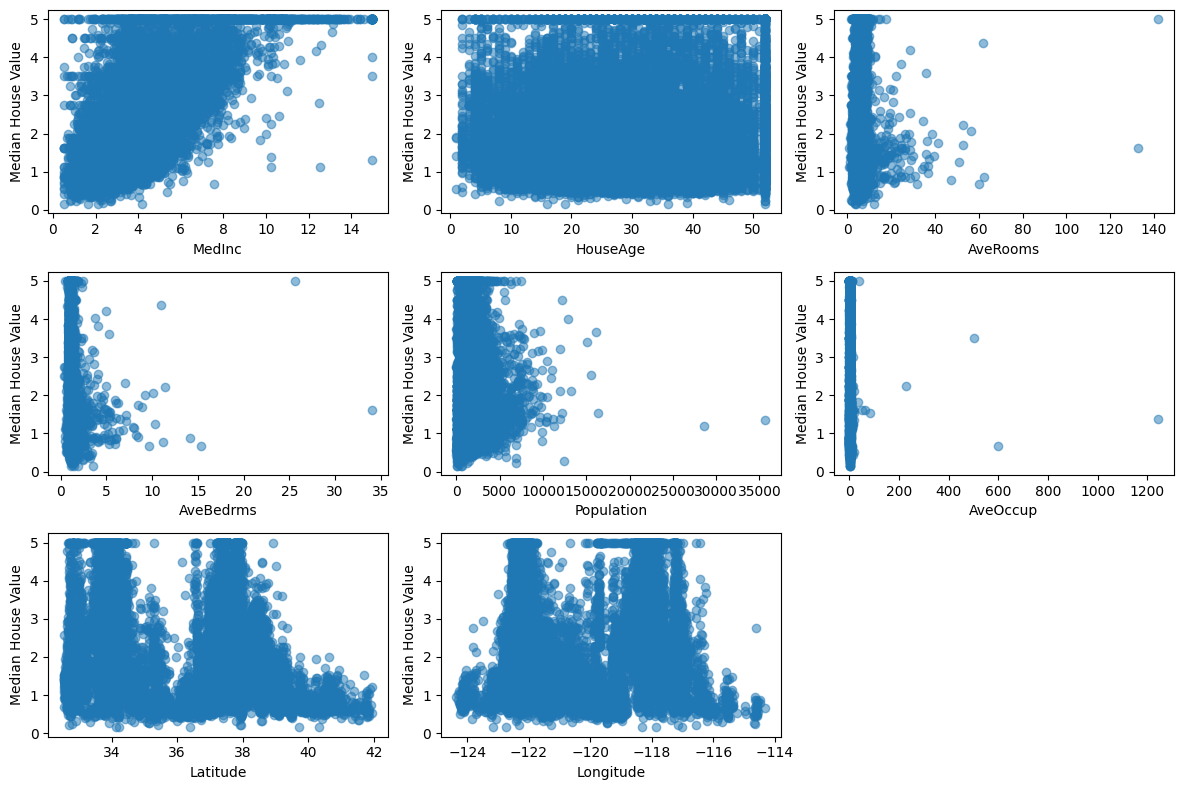

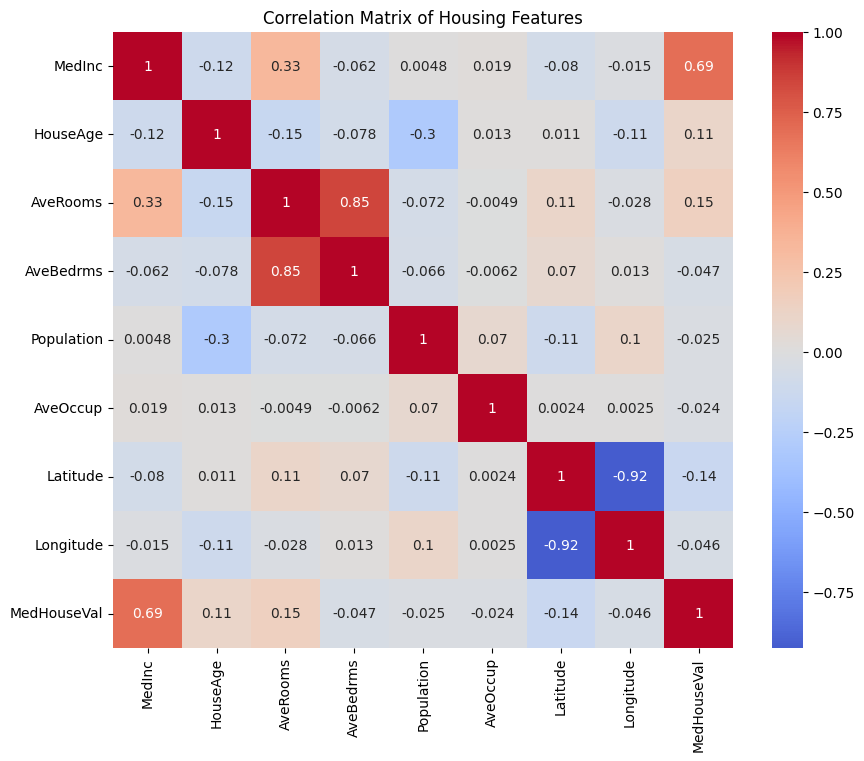


Correlation with target variable:
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

Training set size: (16512, 5)
Testing set size: (4128, 5)

Linear Regression:
  Test R2 Score: 0.5814
  Test MSE: 0.5486
  Test MAE: 0.5433
  CV R2 Mean: 0.5980 (+/- 0.0092)

Ridge Regression:
  Test R2 Score: 0.5814
  Test MSE: 0.5486
  Test MAE: 0.5433
  CV R2 Mean: 0.5980 (+/- 0.0092)

Lasso Regression:
  Test R2 Score: 0.4814
  Test MSE: 0.6796
  Test MAE: 0.6222
  CV R2 Mean: 0.4971 (+/- 0.0082)

Random Forest:
  Test R2 Score: 0.8090
  Test MSE: 0.2503
  Test MAE: 0.3254
  CV R2 Mean: 0.8050 (+/- 0.0072)

Gradient Boosting:
  Test R2 Score: 0.7487
  Test MSE: 0.3293
  Test MAE: 0.3943
  CV R2 Mean: 0.7622 (+/- 0.0044)

Best Model: Random Forest
Best Test R2 Score: 0.8090


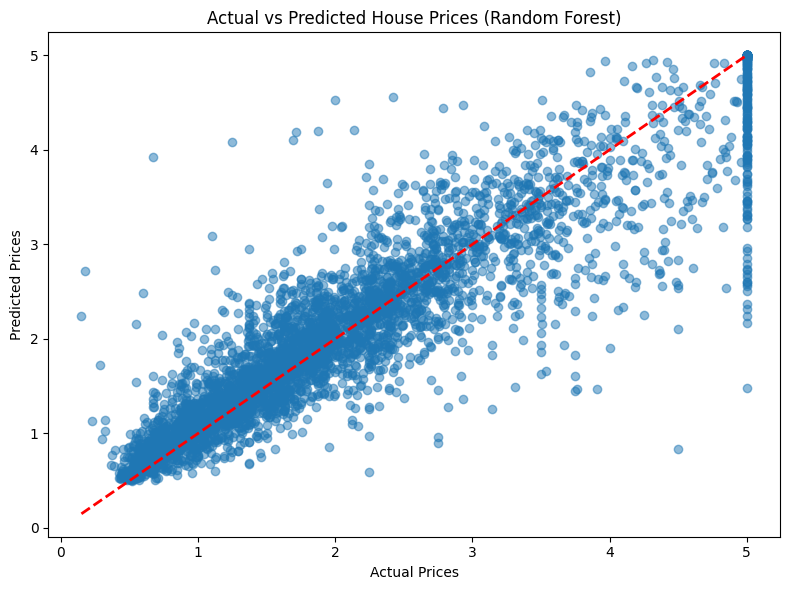

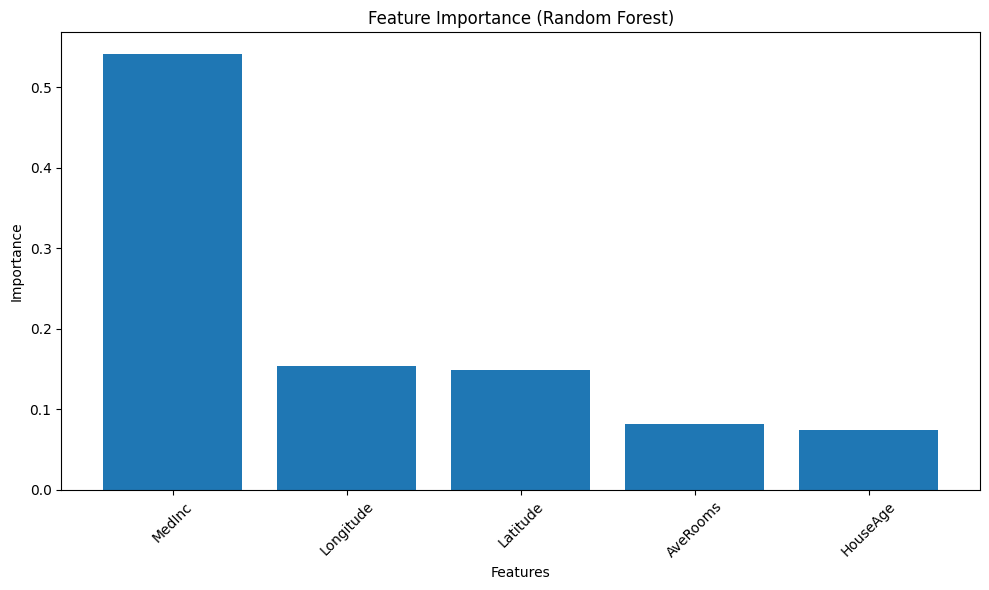


Feature Importance:
     feature  importance
0     MedInc    0.541452
3  Longitude    0.154371
2   Latitude    0.148737
1   AveRooms    0.081259
4   HouseAge    0.074180

Sample Predictions:
Actual: $102000.00 | Predicted: $131985.00 | Difference: $29985.00
Actual: $107300.00 | Predicted: $102736.00 | Difference: $4564.00
Actual: $288800.00 | Predicted: $388090.13 | Difference: $99290.13
Actual: $116700.00 | Predicted: $117445.00 | Difference: $745.00
Actual: $98500.00 | Predicted: $108790.00 | Difference: $10290.00

Model saved as 'housing_price_model.pkl'
Scaler saved as 'housing_scaler.pkl'


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load the California housing dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target  # Target variable (house prices)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Exploratory Data Analysis (EDA)
plt.figure(figsize=(12, 8))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(3, 3, i)
    plt.scatter(df[column], df['MedHouseVal'], alpha=0.5)
    plt.xlabel(column)
    plt.ylabel('Median House Value')
plt.tight_layout()
plt.savefig('housing_relationships.png')
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Housing Features')
plt.savefig('housing_correlation.png')
plt.show()

print("\nCorrelation with target variable:")
print(correlation_matrix['MedHouseVal'].sort_values(ascending=False))

# Feature selection based on correlation
selected_features = ['MedInc', 'AveRooms', 'Latitude', 'Longitude', 'HouseAge']
X = df[selected_features]
y = df['MedHouseVal']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')

    results[name] = {
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Train MSE': train_mse,
        'Test MSE': test_mse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'CV R2 Mean': cv_scores.mean(),
        'CV R2 Std': cv_scores.std()
    }

    print(f"\n{name}:")
    print(f"  Test R2 Score: {test_r2:.4f}")
    print(f"  Test MSE: {test_mse:.4f}")
    print(f"  Test MAE: {test_mae:.4f}")
    print(f"  CV R2 Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Find the best model
best_model_name = max(results, key=lambda x: results[x]['Test R2'])
best_model = models[best_model_name]
print(f"\n{'='*50}")
print(f"Best Model: {best_model_name}")
print(f"Best Test R2 Score: {results[best_model_name]['Test R2']:.4f}")

# Make predictions with the best model
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)

# Plot actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title(f'Actual vs Predicted House Prices ({best_model_name})')
plt.tight_layout()
plt.savefig('housing_predictions.png')
plt.show()

# Feature importance (for tree-based models)
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'feature': selected_features,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title(f'Feature Importance ({best_model_name})')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('housing_feature_importance.png')
    plt.show()

    print("\nFeature Importance:")
    print(feature_importance)

# Sample predictions
sample_indices = np.random.choice(len(X_test), 5, replace=False)
print("\nSample Predictions:")
for idx in sample_indices:
    print(f"Actual: ${y_test.iloc[idx]*100000:.2f} | Predicted: ${y_pred[idx]*100000:.2f} | Difference: ${abs(y_test.iloc[idx]*100000 - y_pred[idx]*100000):.2f}")

# Save the best model
import joblib
joblib.dump(best_model, 'housing_price_model.pkl')
joblib.dump(scaler, 'housing_scaler.pkl')
print("\nModel saved as 'housing_price_model.pkl'")
print("Scaler saved as 'housing_scaler.pkl'")